# Inflation and Nuclear Energy Policy Context
## Core CPI and Long-Term Energy Investment Conditions

## Overview

This notebook analyzes inflation as a macroeconomic condition relevant to nuclear energy 
development. Rather than treating inflation as a direct driver of nuclear outcomes, the 
analysis uses inflation to represent the broader price environment affecting long-term 
capital-intensive infrastructure.

## Research Question

How does the underlying inflation environment help contextualize trends in nuclear 
energy generation over time?

## Why Use Core CPI?

This analysis uses Core CPI (excluding food and energy) to capture underlying inflation 
trends. Headline inflation is excluded because it includes volatile components that can 
distort long-term macroeconomic interpretation.

Core inflation is more appropriate for analyzing infrastructure investment environments, 
as it reflects persistent price pressures relevant to financing and cost conditions.

## Data Frequency and Alignment

Both datasets used in this notebook are monthly time series from FRED. 
The nuclear generation series records monthly electric power generation, while the Core CPI series records monthly price index values.

To support a cleaner long-run comparison, the analysis first calculates monthly year-over-year Core CPI inflation and then converts both nuclear generation and inflation into annual averages. This produces two comparable yearly series for interpretation.

## Data Sources

- Nuclear electric power generation (FRED)
- Core CPI (CPILFESL, FRED)

## Notebook Roadmap

1. Import packages and establish file paths
2. Load the nuclear energy and inflation datasets
3. Inspect structure and clean date fields
4. Prepare comparable time variables
5. Visualize long-term trends
6. Interpret the macroeconomic relevance for nuclear policy analysis

In [1]:
# Packages 
import pandas as pd 
from pathlib import Path 

import seaborn as sns 
import matplotlib.pyplot as plt 

# setting the style of the graph 
sns.set_style("whitegrid")

DATA_DIR = Path("..") / "data"



## Data Loading 

In [2]:
nuclear_generation = pd.read_csv(DATA_DIR/ "IPN221113N.csv")
inflation  = pd.read_csv(DATA_DIR / "CPILFESL.csv")

## Planned Data Inputs

The notebook will later load:
- Nuclear energy dataset
- Core CPI inflation dataset

These will be prepared for long-run comparison using a shared date field and consistent time indexing.

## Data Sources

This analysis uses time-series data from FRED.

| Variable | FRED Code | Description |
|--------|--------|--------|
| Nuclear Electricity Production | IPN221113N | Industrial production index (2017 = 100) |
| Consumer Price Index for all Urban Consumers: All Less Food and Energy in U.S. City Average  | CPILFESL|  Core CPI (Core Inflation)|

## Data Frequency 

|*nuclear generation series is monthly
|-------------------------------------|
*Core CPI series is monthly
*inflation is calculated as monthly YoY
*both series will then be converted to yearly averages for cleaner long-run comparison|

## Initial Data Inspection 

In [3]:
print(nuclear_generation.head(20))



   observation_date  IPN221113N
0        1972-01-01      6.1328
1        1972-02-01      5.5819
2        1972-03-01      6.1460
3        1972-04-01      5.3926
4        1972-05-01      4.2312
5        1972-06-01      5.7189
6        1972-07-01      6.6958
7        1972-08-01      8.3358
8        1972-09-01      7.1274
9        1972-10-01      6.7282
10       1972-11-01      8.0459
11       1972-12-01      8.8052
12       1973-01-01      9.1363
13       1973-02-01      9.6002
14       1973-03-01      9.7258
15       1973-04-01      8.8816
16       1973-05-01      8.3333
17       1973-06-01     10.2540
18       1973-07-01     10.1807
19       1973-08-01     11.3875


In [4]:
print(inflation.head(20))

   observation_date  CPILFESL
0        1957-01-01      28.5
1        1957-02-01      28.6
2        1957-03-01      28.7
3        1957-04-01      28.8
4        1957-05-01      28.8
5        1957-06-01      28.9
6        1957-07-01      29.0
7        1957-08-01      29.0
8        1957-09-01      29.1
9        1957-10-01      29.2
10       1957-11-01      29.3
11       1957-12-01      29.3
12       1958-01-01      29.3
13       1958-02-01      29.4
14       1958-03-01      29.5
15       1958-04-01      29.5
16       1958-05-01      29.5
17       1958-06-01      29.6
18       1958-07-01      29.6
19       1958-08-01      29.6


In [5]:
print(nuclear_generation.info())



<class 'pandas.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  648 non-null    str    
 1   IPN221113N        648 non-null    float64
dtypes: float64(1), str(1)
memory usage: 10.2 KB
None


In [6]:
print(inflation.info())

<class 'pandas.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  830 non-null    str    
 1   CPILFESL          829 non-null    float64
dtypes: float64(1), str(1)
memory usage: 13.1 KB
None


## Data Preparation

Both datasets will be prepared by:
- Converting date columns
- Renaming variables for clarity
- Ensuring consistent time indexing

In [7]:
nuclear_generation['observation_date'] = pd.to_datetime(nuclear_generation['observation_date'])
nuclear_generation = nuclear_generation.sort_values('observation_date')
nuclear_generation['year'] = nuclear_generation['observation_date'].dt.year
nuclear_generation = nuclear_generation.rename(columns={'IPN221113N': 'nuclear_generation'})
nuclear_generation.head(10) # IGNORE for report this is just to check if column was added correctly. 



,observation_date,nuclear_generation,year
0,1972-01-01,6.1328,1972
1,1972-02-01,5.5819,1972
2,1972-03-01,6.1460,1972
3,1972-04-01,5.3926,1972
4,1972-05-01,4.2312,1972
5,1972-06-01,5.7189,1972
6,1972-07-01,6.6958,1972
7,1972-08-01,8.3358,1972
8,1972-09-01,7.1274,1972
9,1972-10-01,6.7282,1972


In [8]:
nuclear_yearly = nuclear_generation.groupby('year')['nuclear_generation'].mean().reset_index()

CPIt - CPIt-12 / CPIt-12 

In [9]:
inflation['observation_date'] = pd.to_datetime(inflation['observation_date'])
inflation = inflation.sort_values('observation_date')
inflation['core_cpi_yoy'] = inflation['CPILFESL'].pct_change(12) * 100
inflation['year'] = inflation['observation_date'].dt.year

In [10]:
inflation_yearly = inflation.groupby('year')['core_cpi_yoy'].mean().reset_index()

In [11]:
# Inspecting described data for inflation. This is just to check if the 
# core_cpi_yoy column was added correctly. IGNORE for report.
inflation.describe().T

,count,mean,min,25%,50%,75%,max,std
observation_date,830,1991-07-17 06:37:18.072289,1957-01-01 00:00:00,1974-04-08 12:00:00,1991-07-16 12:00:00,2008-10-24 06:00:00,2026-02-01 00:00:00,NaN
CPILFESL,829.0,142.310885,28.5,47.9,142.3,216.788,333.512,88.818495
core_cpi_yoy,817.0,3.663185,0.602718,2.010309,2.782324,4.614094,13.604488,2.466347
year,830.0,1991.084337,1957.0,1974.0,1991.0,2008.0,2026.0,19.978399


In [12]:
inflation_yearly = inflation.groupby('year')['core_cpi_yoy'].mean().reset_index()

In [13]:
# Merging the two datasets on the 'year' column. 
merged_df = pd.merge(
    nuclear_yearly,
    inflation_yearly,
    on='year',
    how='inner'
)

In [14]:
merged_df.head()
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                54 non-null     int32  
 1   nuclear_generation  54 non-null     float64
 2   core_cpi_yoy        54 non-null     float64
dtypes: float64(2), int32(1)
memory usage: 1.2 KB


## Trend Visualization

In [15]:
OUTPUT_DIR = Path("..") / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


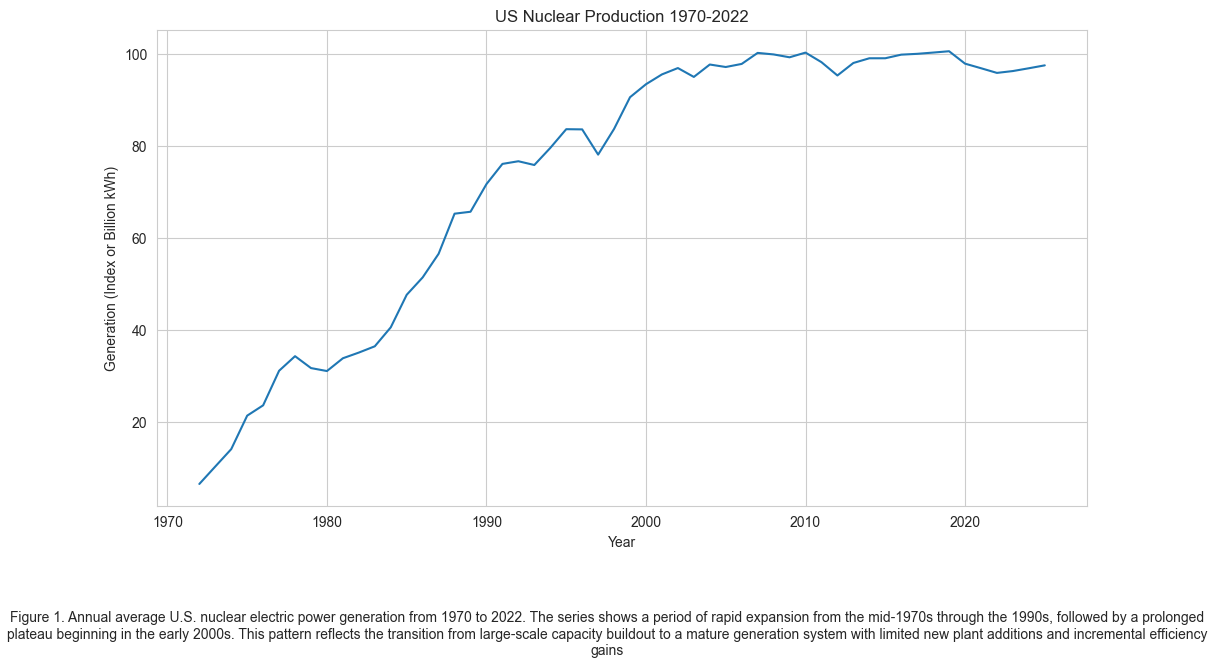

In [16]:
# "U.S. Nuclear Electric Power Generation (Annual Average)"
fig, ax= plt.subplots(figsize = (12,7))
sns.lineplot(data = merged_df, x = 'year', y = 'nuclear_generation')
ax.set_title("US Nuclear Production 1970-2022")
ax.set_xlabel("Year")
ax.set_ylabel('Generation (Index or Billion kWh)')
plt.grid(True)

# Bottom figure development name 
caption_text = "Figure 1. Annual average U.S. nuclear electric power generation from 1970 to 2022. The series shows a period of rapid expansion from the mid-1970s through the 1990s, followed by a prolonged plateau beginning in the early 2000s. This pattern reflects the transition from large-scale capacity buildout to a mature generation system with limited new plant additions and incremental efficiency gains"
fig.subplots_adjust(bottom=0.2)
fig.text(
    0.5,
    0.05, 
    caption_text, 
    ha = 'center',
    va = 'top',
    fontsize = 10,
    wrap = True

)

plt.savefig(OUTPUT_DIR / 'nuclear_generation.png', dpi=300, bbox_inches='tight')
plt.show()



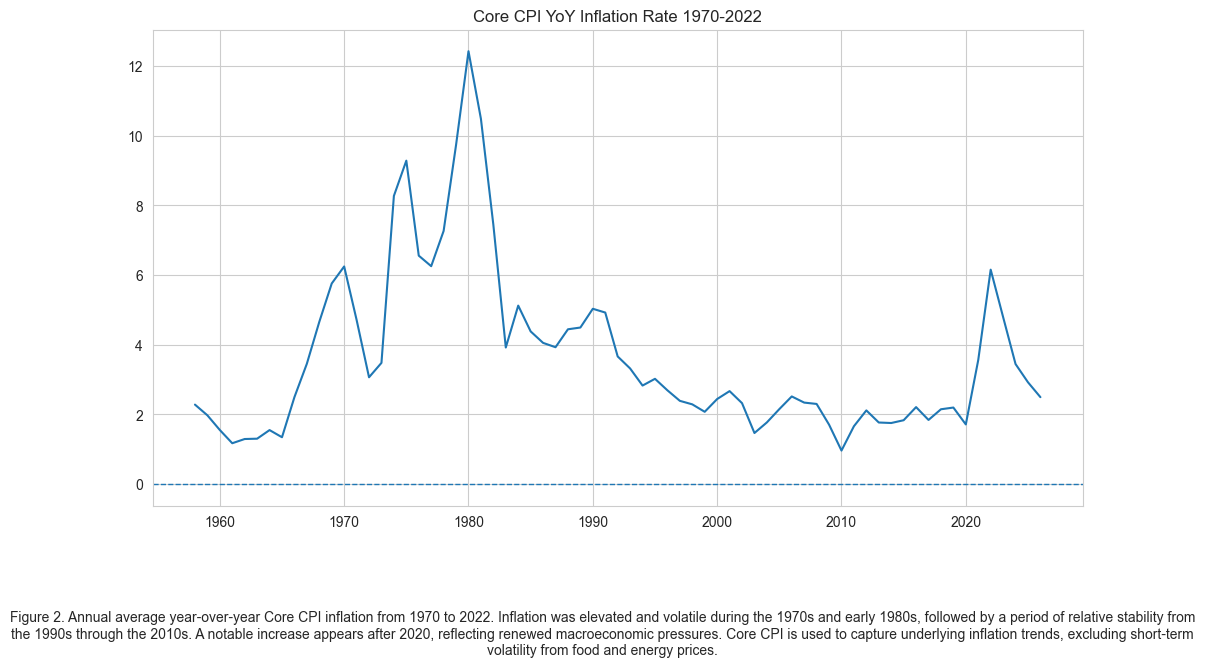

In [17]:
# Core cpi 
fig, ax = plt.subplots(figsize = (12,7))
plt.axhline(0, linestyle='--', linewidth=1)
ax.plot(inflation_yearly['year'], inflation_yearly['core_cpi_yoy'], label = "Core CPI YoY Inflation Rate")
ax.set_title("Core CPI YoY Inflation Rate 1970-2022")

caption_text = "Figure 2. Annual average year-over-year Core CPI inflation from 1970 to 2022. Inflation was elevated and volatile during the 1970s and early 1980s, followed by a period of relative stability from the 1990s through the 2010s. A notable increase appears after 2020, reflecting renewed macroeconomic pressures. Core CPI is used to capture underlying inflation trends, excluding short-term volatility from food and energy prices."
fig.subplots_adjust(bottom=0.2)
fig.text(
    0.5,
    0.05, 
    caption_text, 
    ha = 'center',
    va = 'top',
    fontsize = 10,
    wrap = True

)
plt.savefig(OUTPUT_DIR / 'core_inflation.png', dpi=300, bbox_inches='tight')
plt.show()

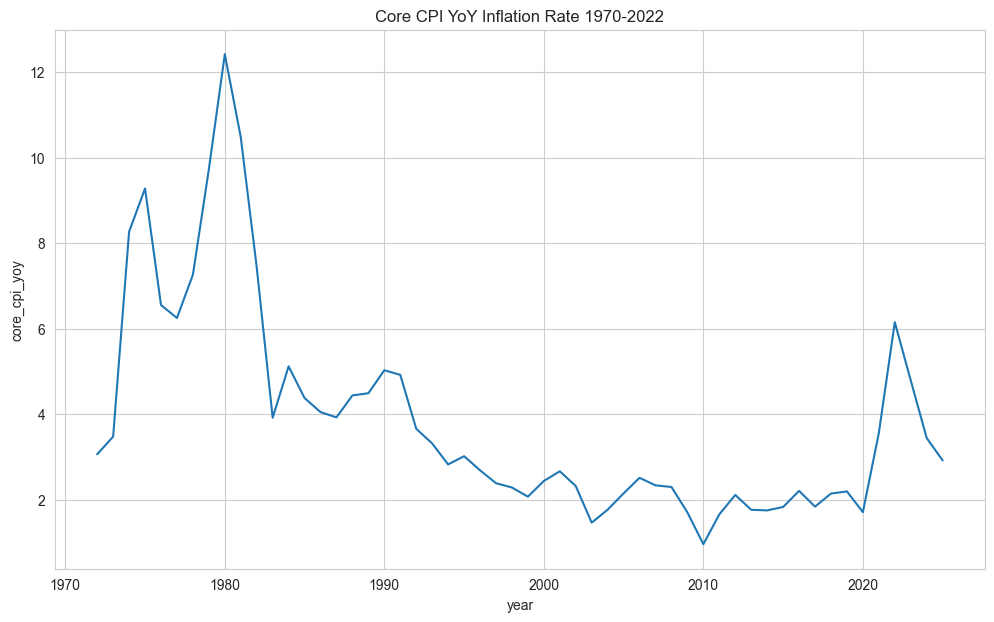

In [18]:
plt.subplots(figsize = (12,7))
sns.lineplot(data = merged_df, x = 'year', y = 'core_cpi_yoy')
plt.title("Core CPI YoY Inflation Rate 1970-2022")
plt.grid(True)
plt.show()

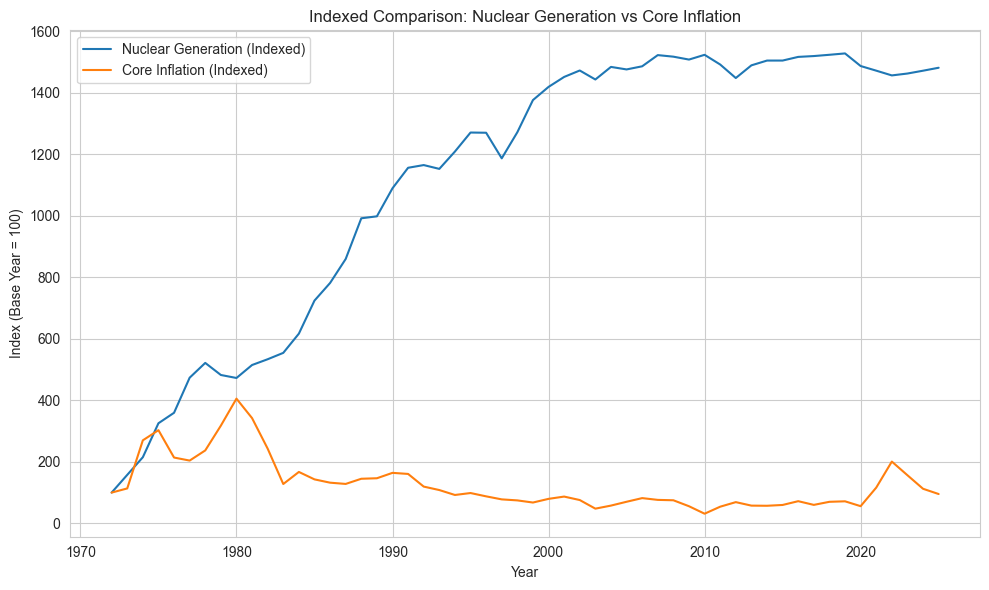

In [19]:
merged_df['nuclear_index'] = merged_df['nuclear_generation'] / merged_df['nuclear_generation'].iloc[0] * 100
merged_df['inflation_index'] = merged_df['core_cpi_yoy'] / merged_df['core_cpi_yoy'].iloc[0] * 100



plt.figure(figsize=(10, 6))

sns.lineplot(data=merged_df, x='year', y='nuclear_index', label='Nuclear Generation (Indexed)')
sns.lineplot(data=merged_df, x='year', y='inflation_index', label='Core Inflation (Indexed)')

plt.title('Indexed Comparison: Nuclear Generation vs Core Inflation')
plt.xlabel('Year')
plt.ylabel('Index (Base Year = 100)')
plt.legend()

plt.tight_layout()

caption_text = "Figure 3. Indexed comparison of U.S. nuclear generation and Core CPI inflation (base year = 100). Indexing allows both series to be compared in relative terms despite differences in units. The figure highlights the rapid growth phase of nuclear generation in earlier decades and its subsequent stabilization, alongside shifting inflation regimes. This comparison is intended to provide macroeconomic context rather than imply a direct causal relationship between inflation and nuclear energy output."
fig.subplots_adjust(bottom=0.2)
fig.text(
    0.5,
    0.05,
    caption_text,
    ha='center',
    va='top',
    fontsize=10,
    wrap=True
)


plt.savefig(OUTPUT_DIR / 'indexed_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretation Draft 

The inflation series is used to represent the broader macroeconomic environment in which 
nuclear energy development occurs. Sustained inflation levels may indicate higher input 
costs, tighter monetary policy, and increased financing constraints for large-scale 
infrastructure projects.


The average annual nuclear power production in the United States finds itself in two developmental stages. Figure 1, represents a developmental trend beginning throughout1970-2000 whereas from the 2000's onward we see a stabilization phase indicating that nuclear power production has matured and maintained its generation patterns following the 2000's. This developmental growth suggests that as the construction of nuclear reactors carried out throughout the corresponding decades, electrical output also increased likely do to a large labour force allowing for greater production output. However, when reflecting on core inflation at that point in time, during the 1970s towards 1980, figure two indicates the volatility inflation was throughout the 1970s and 1980s. Inflation can impact developmental and operating costs for nuclear reactors however, Figure 3 does not suggest or indicate that core inflation impacted average annual electrical output production. 

A potential reason as to why inflation did not significantly impact or stall nuclear energy output is due to the already high upfront costs. Specifically, when developing a nuclear reactor it bring already present high upfront costs and even with inflation having an impact on the cost of materials to develop a plant, high costs are already considered when developing these energy infrastructure projects. Although costs are high, it is predicted to have high profit margins allowing for such a large fiscal capacity or monetary risk. 

When assessing figure 3, it helps to contextualize different developmental patterns in nuclear generation using core inflation as a macroeconomic indicator. As the average inflation rate  from 1970's-2020 was 3%, it gives two distinct pieces of information. Although core inflation was at its peak from the 1960's-1980's. nuclear power generation was at its infancy stage production wise with the predicted expectation that overtime, output would rise. Figure 1 supports this idea provided that the growth from the 1970's-early 2000's could maintain this level of output in its stabilization phase following the early 2000's-present. Although inflation cooled following the 1980's, so did the growth patterns of nuclear energy production as during that time phase development stabilized, and although inflation can bring higher costs and provide fiscal challenges, the already present risks  did not detour production output. This suggests that although inflation did not stall production output, it can give a better idea of where the macroeconomic inflationary trend was at that time, and the risks associated during the developmental and stabilization phases of nuclear energy production in the U.S. 



## Interpretation Finalised 
The average annual nuclear power generation in the United States exhibits two distinct phases of development. As shown in Figure 1, nuclear generation experienced sustained growth from approximately 1970 through the early 2000s, followed by a stabilization phase. This pattern reflects a transition from capacity expansion to a mature system characterized by relatively stable production levels.

Figure 2 illustrates that core inflation was elevated and volatile during the 1970s through the early 1980s, before stabilizing at lower levels in subsequent decades. While inflation can influence costs for large-scale infrastructure projects such as nuclear power plants, a direct relationship between inflation and nuclear generation is not evident in the data.

Figure 3 provides a comparative view of these trends by placing nuclear generation alongside core inflation as a macroeconomic indicator. Although inflation was relatively high during the early stages of nuclear expansion, nuclear output continued to grow. Similarly, the stabilization of nuclear generation in the 2000s does not appear to correspond directly with changes in inflation trends.

One possible explanation is that nuclear energy development is driven primarily by long-term structural and institutional factors, including high upfront capital costs, regulatory frameworks, and long planning horizons. These characteristics may reduce the sensitivity of nuclear generation to fluctuations in inflation. While inflation can affect construction and financing costs, these risks are typically incorporated into project planning and investment decisions.

Overall, the analysis suggests that core inflation serves as a useful indicator of the broader macroeconomic environment rather than a direct determinant of nuclear energy output. The observed trends highlight how nuclear generation evolved through a growth phase into a mature, stabilized system, largely independent of short-term inflationary fluctuations.

## Conclusion

Inflation does not directly determine nuclear energy outcomes, but it provides important 
context for understanding the economic conditions surrounding long-term investment decisions.

## Citation (Data References)
1. U.S. Bureau of Labor Statistics, Consumer Price Index for All Urban Consumers: All Items Less Food and Energy in U.S. City Average [CPILFESL], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/CPILFESL, March 26, 2026.

2. Board of Governors of the Federal Reserve System (US), Industrial Production: Utilities: Nuclear Electric Power Generation (NAICS = 221113) [IPN221113N], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/IPN221113N, March 18, 2026.

## Source Codes 
1. Source Code: CES4422000001
2. Source Code: CPILFESL